# 节点执行与容错机制

## 全局配置（langgraph>=1.2）
- TimeoutPolicy\error_handler\RetryPolicy\CachePolicy均可以通过`StateGraph().set_node_defaults`统一设置，但有版本要求，官方文档参考：https://docs.langchain.com/oss/python/langgraph/fault-tolerance#graph-defaults

### Timeouts(langgraph>=1.2)
    - 超时控制。限制单个节点最大执行时长，避免等待时间过长,超时会抛出`NodeTimeoutError`,该异常会交给RetryPolicy判断是否要重试，重试次数耗尽，进入异常处理
    - 只能支持异步节点，因为python里面的同步函数执行会阻塞当前线程，无法从外部强行终止函数的调用。
    - add_node(timeout=TimeoutPolicy(run_timeout=60))
### Error Handling(langgraph>=1.2)
    - 错误处理。重试次数耗尽之后，执行特定的异常处理逻辑
    - `add_node(error_handler=handle_api_error)`。步骤是：1. 节点抛出异常；2. 是否满足RetryPolicy；3.满足则重试，重试次数耗尽就进入异常处理 4. 异常处理执行

## Retry: 重试机制
    - `add_node(retry_policy=RetryPolicy())`指定重试策略
    - 常见参数：
        - max_attempts: int, 最大重试次数。包括首次节点运行，不是从首次异常开始计数。
        - jitter: bool,是否为重试间隔添加抖动。防止在并发情况下，造成重试瞬时高峰流量。
        - initial_interval: float,首次重试等待事件，默认0.5秒
        - backoff_factor: float,重试等待时间放大倍数，默认2倍
        - max_interval: float,相邻2次重试最大等待时间，默认128秒
        - retry_on: type[Exception] | Sequence[type[Exception]] | Callable[[Exception], bool]，默认default_retry_on,哪些异常需要触发重试
            - 单个异常：RetryPolicy(retry_on=HTTPError)
            - 多个异常：RetryPolicy(retry_on=(HTTPError, TimeoutError))
            - 自定义函数判断，接收异常，返回bool，为True则重试，False不重试
                ```python
                def should_retry(exc: Exception) -> bool:
                         return isinstance(exc, HTTPError)

                RetryPolicy(retry_on=should_retry)
                ```
            - 默认default_retry_on是一个内置函数，会对大都数异常重试，比如会`requests`和`httpx`包下的`5xx`错误码(服务端网关错误、网络异常等)的异常充值，因为4xx异常通常是客户端错误，重试没有异常；而对于TypeError\ArithmeticError这些异常，也不会重试，这类异常通常意味着代码错误，重试没有意义。

2026-08-12 12:01:56.251 | INFO     | __main__:node_a:12 - node a 运行
2026-08-12 12:01:56.752 | INFO     | __main__:node_a:12 - node a 运行
2026-08-12 12:01:57.754 | INFO     | __main__:node_a:12 - node a 运行
2026-08-12 12:01:57.755 | INFO     | __main__:<module>:32 - 重试次数耗尽: 网络连接超时...


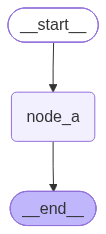

In [3]:
from typing import TypedDict

from langgraph.cache.memory import InMemoryCache
from langgraph.cache.redis import RedisCache
from langgraph.graph import StateGraph, START, END
from langgraph.types import RetryPolicy, CachePolicy

from requests.exceptions import HTTPError
from loguru import logger

class EmptyState(TypedDict):
    pass

def node_a(state: EmptyState) -> EmptyState:
    logger.info(f"node a 运行")
    raise HTTPError("网络连接超时...")

builder = StateGraph(state_schema=EmptyState)
builder.add_node(
    "node_a",
    node_a,
    retry_policy=RetryPolicy(
        max_attempts=3,
        jitter=False
    )
)
builder.add_edge(START, "node_a")
builder.add_edge("node_a", END)

graph = builder.compile()

try:
    graph.invoke({})
except HTTPError as e:
    logger.info("重试次数耗尽: {}", e)

from IPython.display import display
display(graph)

## 节点缓存
- 使用：
    - `add_node(cache_policy=CachePolicy())`
    - `graph.compile(cache=InMemoryCache())`
- `CachePolicy(key_func, ttl)`参数：
    - key_func: 默认是`default_cache_key`，通过`pickle`和节点参数生成缓存key，也可以自定义函数实现逻辑
    - ttl: 过期时间，单位为秒，设置为None，则永不过期

### 采用节点缓存的前提
- 确定性：节点相同的输入返回相同的结果，且相同输入出现频率较高
- 节点执行成本较高：高耗时、复杂计算等


2026-08-12 14:07:06.913 | INFO     | __main__:<module>:33 - 首次调用图
2026-08-12 14:07:06.919 | INFO     | __main__:node_a:15 - node_a 被调用, user: 小明
2026-08-12 14:07:09.920 | INFO     | __main__:node_a:17 - node_a 耗时操作执行完毕
2026-08-12 14:07:09.935 | INFO     | __main__:<module>:34 - 运行结果: {'user': '小明', 'invoke_counts': 1}


2026-08-12 14:07:09.936 | INFO     | __main__:<module>:35 - 相同输入再次调用图
2026-08-12 14:07:09.939 | INFO     | __main__:<module>:36 - 运行结果: {'user': '小明', 'invoke_counts': 1}


2026-08-12 14:07:09.940 | INFO     | __main__:<module>:37 - 不同输入再次调用图
2026-08-12 14:07:09.941 | INFO     | __main__:node_a:15 - node_a 被调用, user: 小花
2026-08-12 14:07:12.942 | INFO     | __main__:node_a:17 - node_a 耗时操作执行完毕
2026-08-12 14:07:12.944 | INFO     | __main__:<module>:38 - 运行结果: {'user': '小花', 'invoke_counts': 1}


2026-08-12 14:07:12.945 | INFO     | __main__:<module>:39 - 不同输入再次调用图
2026-08-12 14:07:12.947 | INFO     | __main__:node_a:15 - node_a 被调用, user: 小花
2026-08-12 14:07:15.948 | INFO

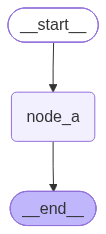

In [4]:
import time
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.cache.memory import InMemoryCache
from langgraph.types import CachePolicy

from operator import add
from loguru import logger

class EmptyState(TypedDict):
    user: str
    invoke_counts: Annotated[int, add]

def node_a(state: EmptyState) -> EmptyState:
    logger.info("node_a 被调用, user: {}", state["user"])
    time.sleep(3) # 模拟耗时操作
    logger.info("node_a 耗时操作执行完毕")

    return {
        "invoke_counts": 1
    }

builder = StateGraph(state_schema=EmptyState)
builder.add_node(
    "node_a",
    node_a,
    cache_policy=CachePolicy(ttl=10)
)
builder.add_edge(START, "node_a")
builder.add_edge("node_a", END)

graph = builder.compile(cache=InMemoryCache())
logger.info("首次调用图")
logger.info("运行结果: {}\n\n", graph.invoke({"user": "小明", "invoke_counts": 0}))
logger.info("相同输入再次调用图")
logger.info("运行结果: {}\n\n", graph.invoke({"user": "小明", "invoke_counts": 0}))
logger.info("不同输入再次调用图")
logger.info("运行结果: {}\n\n", graph.invoke({"user": "小花", "invoke_counts": 0}))
logger.info("不同输入再次调用图")
logger.info("运行结果: {}\n\n", graph.invoke({"user": "小花", "invoke_counts": 2}))
time.sleep(10) # 确保第一次调用缓存失效
logger.info("10秒后相同输入再次调用图，此时缓存已失效")
logger.info("运行结果: {}", graph.invoke({"user": "小明", "invoke_counts": 0}))

from IPython.display import display
display(graph)